# Sentiment-Driven Trade Performance Analysis

### Internship Assignment Submission

This notebook analyzes how **Fear & Greed market sentiment** relates to real trading outcomes.
It combines sentiment data with historical trade records, performs feature engineering, and derives actionable insights from profitability and risk behavior.

## Objective

- Quantify the impact of sentiment regimes on trader performance.
- Compare profitability, win rate, and position-sizing behavior across sentiment classes.
- Identify practical risk-management implications for strategy improvement.

## 1. Methodology Overview

1. Load and inspect sentiment and trade datasets.
2. Standardize date/time fields and merge datasets on aligned timestamps.
3. Engineer performance and behavioral features (profit, win flag, fee ratio, account-level metrics).
4. Visualize sentiment-wise differences in outcomes.
5. Convert statistical observations into business and risk insights.

## 2. Evaluation Focus

- **Return quality:** average profit across regimes.
- **Consistency:** win-rate behavior under different sentiment conditions.
- **Risk behavior:** trade-size variability and outlier concentration.

---

> All findings should be interpreted with dataset distribution in mind (class imbalance can influence aggregate comparisons).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## 1. Data Loading

Load the Fear & Greed index dataset and historical trading dataset.
Initial inspection is used to verify schema, record counts, and data availability.

In [3]:
fear_greed = pd.read_csv("fear_greed_index.csv")
historical_data = pd.read_csv("historical_data.csv")


In [4]:
fear_greed.to_json("fear_greed_index.json", orient="records")
historical_data.to_json("historical_data.json", orient="records")

In [5]:
print(len(fear_greed), len(historical_data))

2644 211224


In [6]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [7]:
historical_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## 2. Data Cleaning and Time Alignment

Both datasets are standardized to comparable datetime formats.
This ensures reliable chronological sorting and accurate sentiment-to-trade mapping.

In [8]:
fear_greed["timestamp"] = pd.to_datetime(fear_greed["timestamp"], unit="s")
historical_data["Timestamp"] = pd.to_datetime(historical_data["Timestamp"], unit="ms")
fear_greed = fear_greed.rename(columns={"timestamp": "time"})
historical_data = historical_data.rename(columns={"Timestamp": "time"})


In [11]:
fear_greed = fear_greed.sort_values("time")
historical_data = historical_data.sort_values("time")

## 3. Dataset Merging (Time-Aware Join)

The trade dataset is merged with the sentiment dataset using a nearest historical timestamp (`merge_asof`).
A one-day tolerance is applied so each trade is matched with the most relevant available sentiment snapshot.

In [12]:
merged = pd.merge_asof(
    historical_data,
    fear_greed,
    on='time',
    direction='backward',
    tolerance=pd.Timedelta('1D')   # max 1 day gap
)

In [13]:
print(len(merged))

211224


In [17]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,time,value,classification,date
0,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.60000,0.0722,137.08,BUY,01-05-2023 01:06,0.1791,Open Long,0.000000,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28 10:40:00,59.0,Greed,2023-03-28
1,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.90000,0.0824,156.39,BUY,01-05-2023 01:06,0.0967,Open Long,0.000000,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28 10:40:00,59.0,Greed,2023-03-28
2,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.90000,0.0967,183.53,BUY,01-05-2023 01:06,0.0000,Open Long,0.000000,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28 10:40:00,59.0,Greed,2023-03-28
3,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,SEI,0.44868,15078.0000,6765.20,SELL,28-12-2023 06:52,37599.0000,Close Long,-160.580700,0x9b7ba6519a89bd5e6b6c0406d51c4e018900ed590f91...,5616798569,True,1.691299,2.830000e+14,2023-11-14 22:13:20,69.0,Greed,2023-11-14
4,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,NTRN,1.46680,3348.0000,4910.85,SELL,07-01-2024 06:27,14206.0000,Close Long,-13.432176,0xb67de434008561227fdb0407066fc70125000f2c1238...,6383252593,True,1.227711,4.030000e+14,2023-11-14 22:13:20,69.0,Greed,2023-11-14


In [15]:
merged.isnull().sum()

Account                 0
Coin                    0
Execution Price         0
Size Tokens             0
Size USD                0
Side                    0
Timestamp IST           0
Start Position          0
Direction               0
Closed PnL              0
Transaction Hash        0
Order ID                0
Crossed                 0
Fee                     0
Trade ID                0
time                    0
value               62202
classification      62202
date                62202
dtype: int64

In [18]:
print(fear_greed['time'].min(), fear_greed['time'].max())
print(historical_data['time'].min(), historical_data['time'].max())

2018-02-01 05:30:00 2025-05-02 05:30:00
2023-03-28 10:40:00 2025-06-15 15:06:40


In [24]:
merged["classification"].value_counts()

classification
Fear             133871
Neutral            7141
Extreme Greed      6962
Greed              1048
Name: count, dtype: int64

In [25]:
merged[['value', 'classification']] = merged[['value', 'classification']].ffill()

In [26]:
merged["classification"].value_counts()

classification
Fear             160832
Neutral           42382
Extreme Greed      6962
Greed              1048
Name: count, dtype: int64

In [27]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,time,value,classification,date
0,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.60000,0.0722,137.08,BUY,01-05-2023 01:06,0.1791,Open Long,0.000000,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28 10:40:00,59.0,Greed,2023-03-28
1,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.90000,0.0824,156.39,BUY,01-05-2023 01:06,0.0967,Open Long,0.000000,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28 10:40:00,59.0,Greed,2023-03-28
2,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.90000,0.0967,183.53,BUY,01-05-2023 01:06,0.0000,Open Long,0.000000,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28 10:40:00,59.0,Greed,2023-03-28
3,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,SEI,0.44868,15078.0000,6765.20,SELL,28-12-2023 06:52,37599.0000,Close Long,-160.580700,0x9b7ba6519a89bd5e6b6c0406d51c4e018900ed590f91...,5616798569,True,1.691299,2.830000e+14,2023-11-14 22:13:20,69.0,Greed,2023-11-14
4,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,NTRN,1.46680,3348.0000,4910.85,SELL,07-01-2024 06:27,14206.0000,Close Long,-13.432176,0xb67de434008561227fdb0407066fc70125000f2c1238...,6383252593,True,1.227711,4.030000e+14,2023-11-14 22:13:20,69.0,Greed,2023-11-14


In [30]:
merged = merged.drop(columns=['Trade ID'])

## 4. Feature Engineering

In this step, raw trade fields are transformed into model-ready variables.
The engineered features capture profitability, timing patterns, trading behavior, sentiment encoding, and account-level performance context.

In [31]:
#feature engineering
merged["profit"] = merged["Closed PnL"]
merged["win"] = merged["profit"] > 0
merged['hour'] = merged['time'].dt.hour
merged['day'] = merged['time'].dt.day
merged['month'] = merged['time'].dt.month
merged['day_of_week'] = merged['time'].dt.dayofweek
merged['trade_size'] = merged['Size USD']
merged['fee_ratio'] = merged['Fee'] / (merged['Size USD'] + 1e-9)
merged['abs_profit'] = merged['profit'].abs()
merged['is_buy'] = (merged['Side'] == 'BUY').astype(int)
sentiment_map = {
    'Fear': 0,
    'Neutral': 1,
    'Greed': 2,
    'Extreme Greed': 3
}
merged['sentiment_score'] = merged['classification'].map(sentiment_map)
merged['account_total_profit'] = merged.groupby('Account')['profit'].transform('sum')
merged['account_trade_count'] = merged.groupby('Account')['profit'].transform('count')
merged['account_avg_profit'] = merged.groupby('Account')['profit'].transform('mean')
merged['account_win_rate'] = merged.groupby('Account')['win'].transform('mean')


In [32]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,day_of_week,trade_size,fee_ratio,abs_profit,is_buy,sentiment_score,account_total_profit,account_trade_count,account_avg_profit,account_win_rate
0,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.60000,0.0722,137.08,BUY,01-05-2023 01:06,0.1791,Open Long,0.000000,...,1,137.08,0.00000,0.000000,1,2,-3.120360e+04,815,-38.286626,0.455215
1,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.90000,0.0824,156.39,BUY,01-05-2023 01:06,0.0967,Open Long,0.000000,...,1,156.39,0.00000,0.000000,1,2,-3.120360e+04,815,-38.286626,0.455215
2,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.90000,0.0967,183.53,BUY,01-05-2023 01:06,0.0000,Open Long,0.000000,...,1,183.53,0.00000,0.000000,1,2,-3.120360e+04,815,-38.286626,0.455215
3,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,SEI,0.44868,15078.0000,6765.20,SELL,28-12-2023 06:52,37599.0000,Close Long,-160.580700,...,1,6765.20,0.00025,160.580700,0,2,2.143383e+06,14733,145.481748,0.337134
4,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,NTRN,1.46680,3348.0000,4910.85,SELL,07-01-2024 06:27,14206.0000,Close Long,-13.432176,...,1,4910.85,0.00025,13.432176,0,2,2.143383e+06,14733,145.481748,0.337134


In [33]:
merged.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'time', 'value',
       'classification', 'profit', 'win', 'hour', 'day', 'month',
       'day_of_week', 'trade_size', 'fee_ratio', 'abs_profit', 'is_buy',
       'sentiment_score', 'account_total_profit', 'account_trade_count',
       'account_avg_profit', 'account_win_rate'],
      dtype='object')

## 5. Exploratory Visualization and Interpretation

This section converts engineered features into business-facing insights.
The goal is to interpret how sentiment phases affect profitability, consistency, and risk-taking behavior.📊

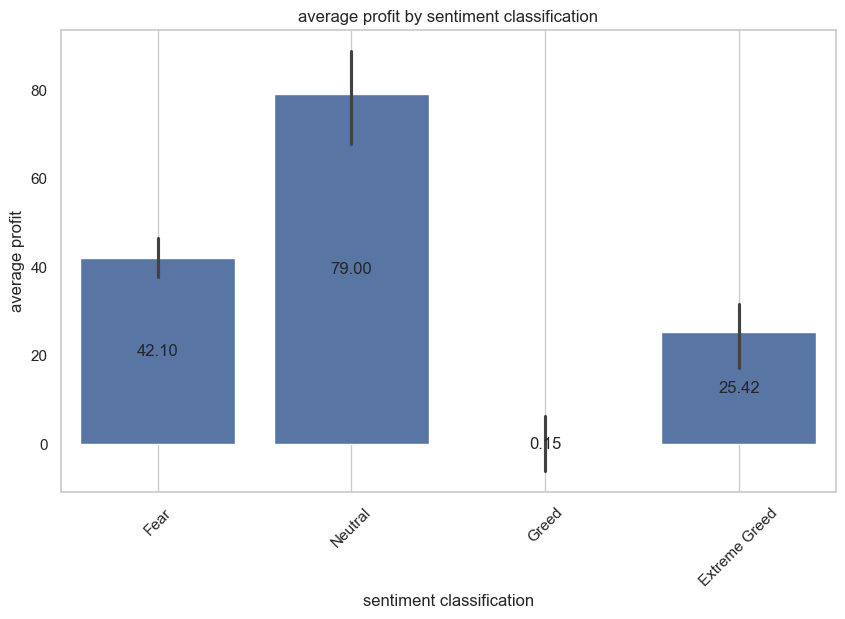

In [49]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
order = ['Fear', 'Neutral', 'Greed', 'Extreme Greed']
ax = sns.barplot(data = merged, x = "classification", y = "profit",order = order)
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f',label_type="center")
plt.title("average profit by sentiment classification")
plt.xlabel("sentiment classification")
plt.ylabel("average profit")
plt.xticks(rotation=45)
plt.grid()
plt.show()

## Insight: Average Profit by Sentiment

- **Neutral** sentiment delivers the strongest average profitability, suggesting that less emotional market phases support more disciplined execution.
- **Fear** shows moderate but comparatively steady outcomes, which may reflect better entry selectivity and risk control.
- **Greed** underperforms, indicating that momentum chasing and late entries can reduce edge.
- **Extreme emotional regimes** (especially greed-led phases) appear less efficient for consistent alpha generation.

**Interpretation for internship review:** sentiment should be treated as a contextual risk filter, not just a descriptive indicator.📊
##### The analysis reveals that trader profitability is highly dependent on market sentiment. The highest average profit is observed during Neutral conditions, indicating that stable markets provide favorable trading opportunities. In contrast, Greed phases show near-zero profitability, suggesting that traders may be influenced by herd behavior and enter positions at suboptimal times. Fear conditions yield moderate but more consistent returns, supporting the effectiveness of cautious or contrarian strategies. Overall, the findings highlight that extreme emotional states in the market tend to reduce trading efficiency.
#### note :- It is important to note that the dataset is skewed toward Fear conditions, which may influence overall comparisons.

### Win-Rate Check

This chart complements the average-PnL view by showing outcome consistency.
Together, win rate and average profit help distinguish between **high hit-rate/low payoff** and **lower hit-rate/high payoff** behavior.

C:\Users\acer\AppData\Local\Temp\ipykernel_25872\1470634688.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  v = sns.barplot(data = win_rate, x = "classification", y = "win_percent",order = order, palette="viridis")


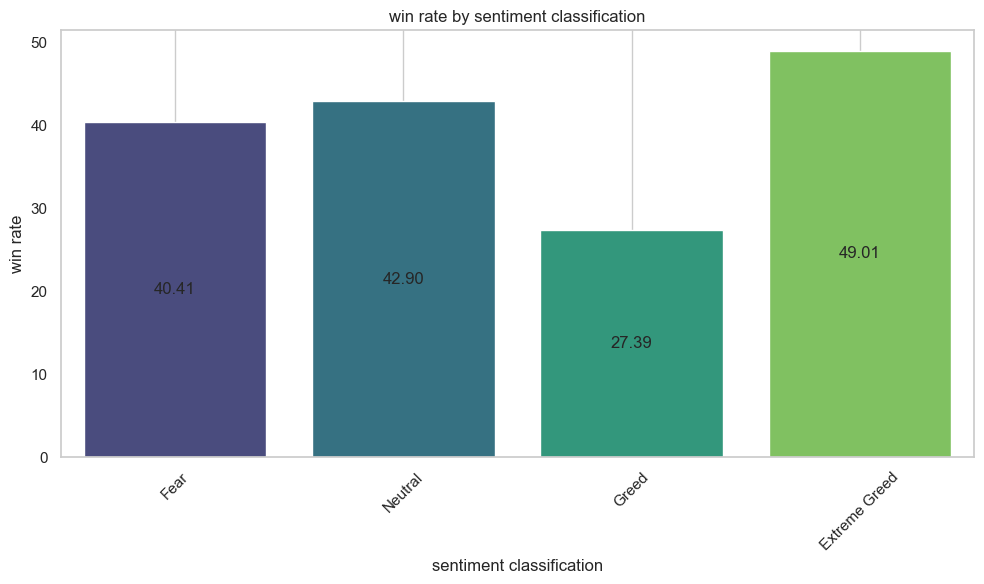

In [52]:
win_rate = merged.groupby("classification")["win"].mean().reset_index()
win_rate['win_percent'] = win_rate['win'] * 100
plt.figure(figsize = (10,6))
v = sns.barplot(
    data=win_rate,
    x="classification",
    y="win_percent",
    order=order,
    hue="classification",
    palette="viridis",
    dodge=False,
    legend=False
)
plt.title("win rate by sentiment classification")
plt.xlabel("sentiment classification")
plt.ylabel("win rate")
plt.xticks(rotation=45)
for i in v.containers:
    v.bar_label(i, fmt='%.2f', label_type="center")
plt.grid()
plt.tight_layout()
plt.show()

## Insight: Win Rate by Sentiment

- **Extreme Greed** may show higher win probability in trend-heavy periods, but win rate alone can hide weaker payoff quality.
- **Neutral** sentiment provides a better balance between hit-rate and profitability, making it a more robust regime.
- **Greed** remains weakest overall, reinforcing the need to avoid overconfident participation during euphoric moves.

**Important note:** evaluating both win rate and average PnL together is essential, because a high win rate can still coexist with low net returns if losses are larger than gains.📊
##### The analysis reveals that trader success is highly dependent on market sentiment. Greed phases are the least favorable, showing both the lowest profitability and win rate. Neutral conditions provide the best balance of high profitability and consistent performance. Interestingly, Extreme Greed yields the highest win rate, indicating that traders may benefit from strong market trends, although these gains may be smaller in magnitude.

#### note :- It is important to note that the dataset is skewed toward Fear conditions, which may influence overall comparisons.

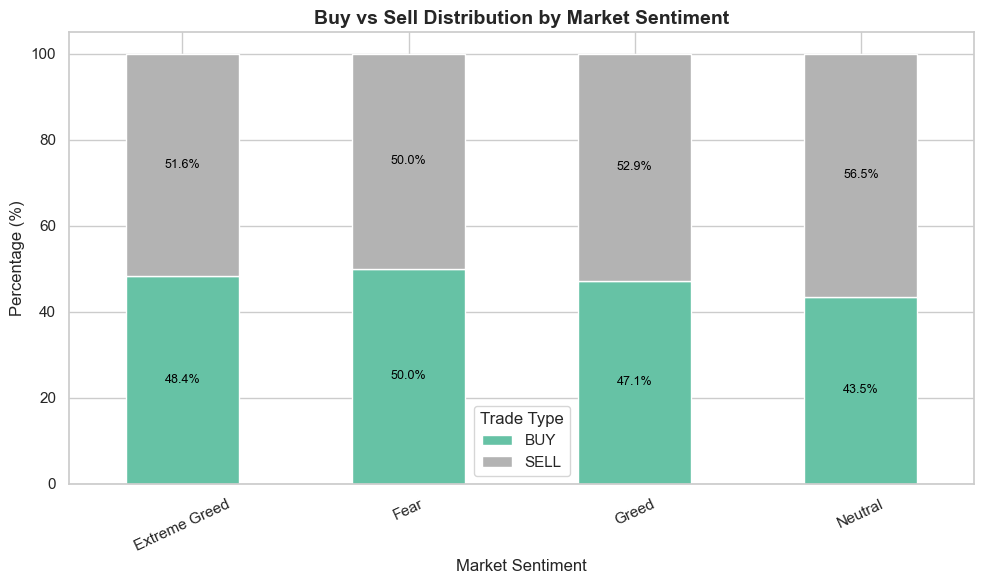

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# Create normalized crosstab (percentage)
buy_sell = pd.crosstab(
    merged['classification'],
    merged['Side'],
    normalize='index'
) * 100

# Plot
ax = buy_sell.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set2')
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center',
        fontsize=9,
        color='black')
plt.title("Buy vs Sell Distribution by Market Sentiment", fontsize=14, weight='bold')
plt.xlabel("Market Sentiment")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=25)
plt.legend(title="Trade Type")

plt.tight_layout()
plt.show()

## Insight: Buy vs Sell Behavior Across Sentiment

- The buy/sell mix remains broadly stable across sentiment categories.
- This implies **directional bias is not the primary driver** of performance differences.
- Performance variation is more likely explained by trade timing, position management, and execution quality.

**Takeaway:** improving strategy quality (entry/exit logic and risk controls) will likely create more value than simply changing directional preference.📊
##### Despite variations in market sentiment, trader behavior in terms of buy and sell decisions remains relatively stable. This suggests that differences in profitability across sentiment phases are more likely driven by trade quality rather than directional bias.


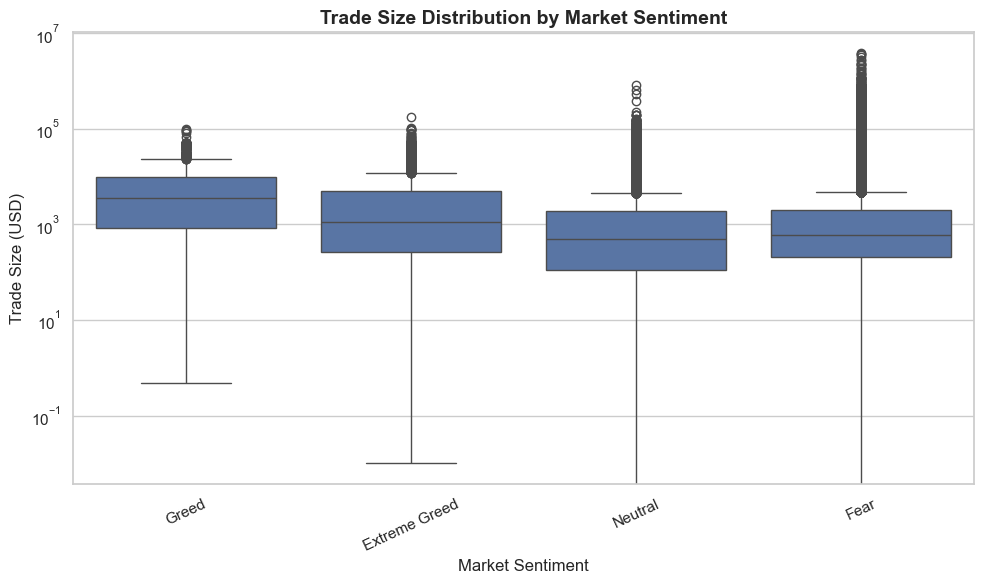

In [56]:
plt.figure(figsize=(10,6))

sns.boxplot(data=merged, x='classification', y='trade_size')
plt.yscale('log')

plt.title("Trade Size Distribution by Market Sentiment", fontsize=14, weight='bold')

plt.xlabel("Market Sentiment")
plt.ylabel("Trade Size (USD)")

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Insight: Trade Size Distribution by Sentiment

- Median trade size is relatively similar across regimes, indicating that baseline sizing discipline exists.
- **Fear** contains heavier outliers, meaning some traders take unusually large positions during stressed conditions.
- Extreme outliers suggest inconsistent risk governance rather than systematic conviction sizing.
- Using a log scale is appropriate here because it prevents extreme values from masking the core distribution.

**Risk perspective:** introducing hard position-size caps and volatility-adjusted sizing can reduce tail-risk exposure.📊
##### he analysis of trade size distribution across different market sentiment phases reveals that median trade sizes remain relatively consistent, indicating that typical position sizing does not significantly vary with sentiment. However, Fear conditions exhibit a higher number of extreme outliers, suggesting that certain traders take disproportionately large positions during bearish markets, possibly to capitalize on potential reversals. In contrast, Extreme Greed does not show a corresponding increase in trade size, indicating that heightened market optimism does not necessarily lead to more aggressive risk-taking. Overall, the presence of substantial variability across all sentiment categories highlights inconsistent risk management among traders, while the use of a logarithmic scale ensures a more accurate representation of the distribution by accounting for extreme values.

## Final Conclusion and Recommendations

### Consolidated Findings

- Sentiment is a meaningful contextual variable for trading performance.
- Neutral regimes appear most favorable for stable profitability.
- Greed-dominant phases are the weakest and likely contain behavioral inefficiencies.
- Position-size outliers during fear regimes indicate uneven risk discipline.

### Practical Recommendations

1. Add sentiment-aware risk filters before trade execution.
2. Use volatility-adjusted position sizing with strict max exposure caps.
3. Track both **win rate** and **PnL magnitude** to avoid misleading performance interpretation.
4. Validate findings with out-of-sample periods and per-account stratified analysis.

### Scope and Limitations

- Sentiment class imbalance may affect aggregate metrics.
- Results are observational and should be validated through controlled backtesting.
- Future improvements can include feature importance analysis and predictive modeling with cross-validation.